<a href="https://colab.research.google.com/github/Dessoka/Assignment-11-I-C/blob/main/Project_2_DCP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build a fresh modeling dataset from Project 1 data

We’ll merge your cleaned prices with metadata again and call it df_model.

In [3]:
import pandas as pd

prices_path = "/content/historical_blocks_prices.csv"
stocks_path = "/content/Historical stocks.csv"

df_prices = pd.read_csv(prices_path)
df_stocks = pd.read_csv(stocks_path)


Recreate df_prices_clean and df_stocks_clean

In [4]:
# Convert date
df_prices["date"] = pd.to_datetime(df_prices["date"])

# Clean numeric columns
num_cols = ["open", "high", "low", "close", "adj_close", "volume"]
for c in num_cols:
    df_prices[c] = pd.to_numeric(df_prices[c], errors="coerce")

# Drop rows missing critical fields
df_prices_clean = df_prices.dropna(subset=["ticker", "date"] + num_cols).copy()

# Set date as index
df_prices_clean = df_prices_clean.set_index("date")

# Clean stocks metadata
df_stocks_clean = df_stocks.dropna(subset=["ticker"]).copy()
df_stocks_clean["sector"] = df_stocks_clean["sector"].fillna("Unknown")
df_stocks_clean["industry"] = df_stocks_clean["industry"].fillna("Unknown")


Now i will  run Project 2 Cell 1 (build df_model)

This creates the dataset i  need for the rest of the assignment.

In [5]:
df_prices_reset = df_prices_clean.reset_index()   # bring date out of index

df_model = df_prices_reset.merge(
    df_stocks_clean,
    on="ticker",
    how="left"
)

df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values(["ticker", "date"]).reset_index(drop=True)

df_model.head()


,date,ticker,open,close,adj_close,low,high,volume,exchange,name,sector,industry
0,1980-12-12,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
1,1980-12-15,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
2,1980-12-16,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
3,1980-12-17,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
4,1980-12-18,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING


In [6]:
numeric_cols = ["open", "high", "low", "close", "adj_close", "volume"]
cat_cols = [c for c in ["sector", "industry", "exchange"] if c in df_model.columns]

df_model[numeric_cols] = (
    df_model
    .groupby("ticker")[numeric_cols]
    .transform(lambda g: g.interpolate().ffill().bfill())
)

for c in cat_cols:
    df_model[c] = df_model[c].fillna("Unknown")

print(df_model[numeric_cols + cat_cols].isna().sum())


open         0
high         0
low          0
close        0
adj_close    0
volume       0
sector       0
industry     0
exchange     0
dtype: int64


In [7]:
# Project 2 - Cell 2: advanced missing value handling

numeric_cols = ["open", "high", "low", "close", "adj_close", "volume"]
cat_cols = [c for c in ["sector", "industry", "exchange"] if c in df_model.columns]

# 1) Numeric: interpolate within each ticker, then ffill/bfill
df_model[numeric_cols] = (
    df_model
    .groupby("ticker")[numeric_cols]
    .transform(lambda g: g.interpolate().ffill().bfill())
)

# 2) Categorical: fill missing with 'Unknown'
for c in cat_cols:
    df_model[c] = df_model[c].fillna("Unknown")

# 3) Check remaining missing values
print(df_model[numeric_cols + cat_cols].isna().sum())


open         0
high         0
low          0
close        0
adj_close    0
volume       0
sector       0
industry     0
exchange     0
dtype: int64


Error checks & corrections

We’ll search for obvious data errors (e.g., negative prices/volumes) and correct them

In [9]:
import numpy as np   # <-- REQUIRED FIX

# Project 2 - Cell 3: error identification & correction

# Check for impossible values
for col in ["open", "high", "low", "close", "adj_close", "volume"]:
    print(col, "min:", df_model[col].min())

# Replace negative or zero prices with NaN then re-impute
price_cols = ["open", "high", "low", "close", "adj_close"]
for col in price_cols:
    invalid_mask = df_model[col] <= 0
    df_model.loc[invalid_mask, col] = np.nan

# Replace negative volume with NaN
invalid_vol = df_model["volume"] < 0
df_model.loc[invalid_vol, "volume"] = np.nan

# Re-run interpolation after fixing bad values
df_model[price_cols + ["volume"]] = (
    df_model
    .groupby("ticker")[price_cols + ["volume"]]
    .transform(lambda g: g.interpolate().ffill().bfill())
)

# Drop any rows still missing critical numeric data
df_model = df_model.dropna(subset=price_cols + ["volume"]).reset_index(drop=True)

print("Shape after error correction:", df_model.shape)


open min: 0.005
high min: 0.005
low min: 0.005
close min: 0.005
adj_close min: 1.46e-05
volume min: 1
Shape after error correction: (1048575, 12)


Outlier detection & capping (close, volume)

We’ll use an IQR-based winsorization (capping) for close and volume.

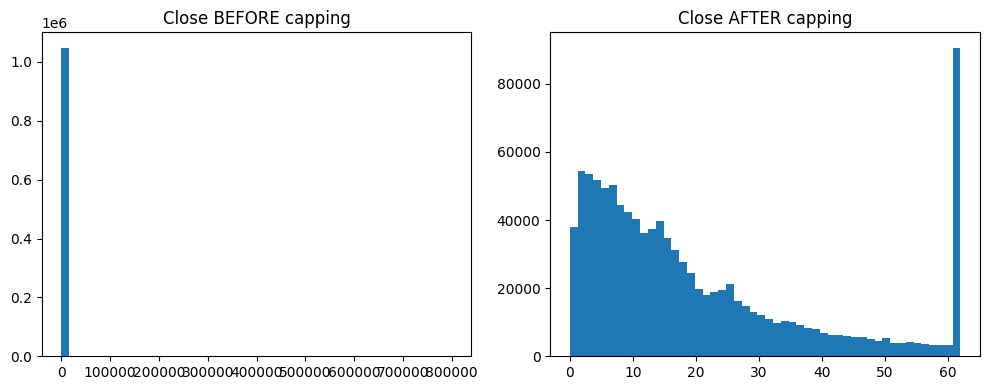

In [11]:
import matplotlib.pyplot as plt   # <-- REQUIRED FIX

# Quick visual check (before vs after)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df_model["close_orig"], bins=50)
plt.title("Close BEFORE capping")

plt.subplot(1,2,2)
plt.hist(df_model["close"], bins=50)
plt.title("Close AFTER capping")

plt.tight_layout()
plt.show()


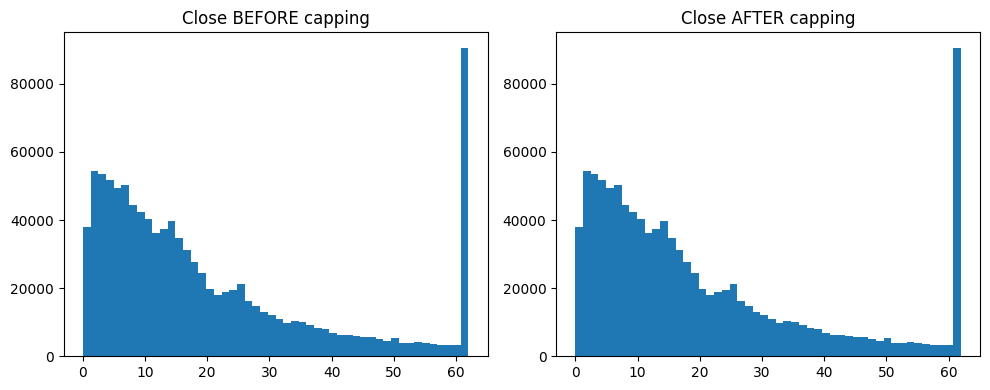

In [12]:
# Project 2 - Cell 4: outlier detection & capping

def cap_outliers(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower, upper)

# Save original for comparison (optional)
df_model["close_orig"] = df_model["close"]
df_model["volume_orig"] = df_model["volume"]

# Cap outliers
df_model["close"] = cap_outliers(df_model["close"])
df_model["volume"] = cap_outliers(df_model["volume"])

# Quick visual check (before vs after) – optional but nice for your report
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df_model["close_orig"], bins=50)
plt.title("Close BEFORE capping")

plt.subplot(1,2,2)
plt.hist(df_model["close"], bins=50)
plt.title("Close AFTER capping")
plt.tight_layout()
plt.show()


Feature engineering (returns, rolling stats, volatility)

We’ll add:

Daily return

Log return

5-day & 20-day moving averages

20-day rolling volatility (std of returns)

20-day rolling average volume

In [14]:
# Project 2 - Cell 5: FIXED feature engineering

df_model = df_model.sort_values(["ticker", "date"]).reset_index(drop=True)
g = df_model.groupby("ticker")

# 1) Daily return
df_model["return_1d"] = g["close"].pct_change()

# 2) Log return (use transform, not apply)
df_model["log_return_1d"] = g["close"].transform(lambda s: np.log(s)).diff()

# 3) Moving averages
df_model["ma_5"] = g["close"].transform(lambda s: s.rolling(5, min_periods=1).mean())
df_model["ma_20"] = g["close"].transform(lambda s: s.rolling(20, min_periods=1).mean())

# 4) Rolling volatility (20-day std of returns)
df_model["vol_20"] = g["return_1d"].transform(lambda s: s.rolling(20, min_periods=5).std())

# 5) Rolling avg volume
df_model["vol_avg_20"] = g["volume"].transform(lambda s: s.rolling(20, min_periods=1).mean())

df_model.head()


,date,ticker,open,close,adj_close,low,high,volume,exchange,name,sector,industry,close_orig,volume_orig,return_1d,log_return_1d,ma_5,ma_20,vol_20,vol_avg_20
0,1980-12-12,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,1147850.0,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING,0.513393,1147850.0,NaN,NaN,0.513393,0.513393,NaN,1147850.0
1,1980-12-15,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,1147850.0,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING,0.486607,1147850.0,-0.052174,-0.053584,0.500000,0.500000,NaN,1147850.0
2,1980-12-16,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,1147850.0,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING,0.450893,1147850.0,-0.073394,-0.076227,0.483631,0.483631,NaN,1147850.0
3,1980-12-17,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,1147850.0,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING,0.462054,1147850.0,0.024752,0.024451,0.478237,0.478237,NaN,1147850.0
4,1980-12-18,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,1147850.0,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING,0.475446,1147850.0,0.028986,0.028573,0.477679,0.477679,NaN,1147850.0


Create a target variable for modeling

Example target: next-day return.

In [15]:
# Project 2 - Cell 6: create target variable (next-day return)

df_model["target_return_1d"] = (
    df_model
    .groupby("ticker")["return_1d"]
    .shift(-1)           # next day's return
)

# Drop rows where target is missing (usually last day per ticker)
df_model = df_model.dropna(subset=["target_return_1d"]).reset_index(drop=True)

df_model[["ticker", "date", "return_1d", "target_return_1d"]].head()


,ticker,date,return_1d,target_return_1d
0,AAPL,1980-12-12,NaN,-0.052174
1,AAPL,1980-12-15,-0.052174,-0.073394
2,AAPL,1980-12-16,-0.073394,0.024752
3,AAPL,1980-12-17,0.024752,0.028986
4,AAPL,1980-12-18,0.028986,0.061033


Encode categorical variables (one-hot)

We’ll one-hot encode sector, industry, exchange.

In [16]:
# Project 2 - Cell 7: one-hot encode categorical variables

cat_cols = [c for c in ["sector", "industry", "exchange"] if c in df_model.columns]

df_model_encoded = pd.get_dummies(
    df_model,
    columns=cat_cols,
    drop_first=True  # avoid dummy variable trap
)

print("Shape after encoding:", df_model_encoded.shape)
df_model_encoded.head()


Shape after encoding: (1048274, 106)


,date,ticker,open,close,adj_close,low,high,volume,name,close_orig,...,industry_SEMICONDUCTORS,industry_SERVICES-MISC. AMUSEMENT & RECREATION,industry_SPECIALTY CHEMICALS,industry_STEEL/IRON ORE,industry_TELECOMMUNICATIONS EQUIPMENT,industry_TELEVISION SERVICES,industry_TEXTILES,industry_TRANSPORTATION SERVICES,industry_Unknown,exchange_NYSE
0,1980-12-12,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,1147850.0,APPLE INC.,0.513393,...,False,False,False,False,False,False,False,False,False,False
1,1980-12-15,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,1147850.0,APPLE INC.,0.486607,...,False,False,False,False,False,False,False,False,False,False
2,1980-12-16,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,1147850.0,APPLE INC.,0.450893,...,False,False,False,False,False,False,False,False,False,False
3,1980-12-17,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,1147850.0,APPLE INC.,0.462054,...,False,False,False,False,False,False,False,False,False,False
4,1980-12-18,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,1147850.0,APPLE INC.,0.475446,...,False,False,False,False,False,False,False,False,False,False


Normalize / standardize numeric features

We’ll standardize a set of numeric features using StandardScaler and add _scaled versions.

In [17]:
# Project 2 - Cell 8: standardize numeric features

from sklearn.preprocessing import StandardScaler

# Choose numeric features to scale (original + engineered)
scale_cols = [
    "open", "high", "low", "close", "adj_close", "volume",
    "return_1d", "log_return_1d",
    "ma_5", "ma_20", "vol_20", "vol_avg_20"
]

# Some columns like return_1d may still have NaNs at the very start; fill with 0 for scaling
df_scaled = df_model_encoded.copy()
df_scaled[scale_cols] = df_scaled[scale_cols].fillna(0.0)

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_scaled[scale_cols])

scaled_col_names = [c + "_scaled" for c in scale_cols]
df_scaled[scaled_col_names] = scaled_values

print("Scaled dataset shape:", df_scaled.shape)
df_scaled[scaled_col_names].head()


Scaled dataset shape: (1048274, 118)


,open_scaled,high_scaled,low_scaled,close_scaled,adj_close_scaled,volume_scaled,return_1d_scaled,log_return_1d_scaled,ma_5_scaled,ma_20_scaled,vol_20_scaled,vol_avg_20_scaled
0,-0.020932,-0.019976,-0.021209,-1.097422,-0.018847,2.03448,-0.003440,-0.000057,-1.097807,-1.098559,-0.020177,2.141969
1,-0.020941,-0.019985,-0.021219,-1.098887,-0.018848,2.03448,-0.019326,-0.813191,-1.098540,-1.099293,-0.020177,2.141969
2,-0.020953,-0.019996,-0.021232,-1.100840,-0.018848,2.03448,-0.025787,-1.156797,-1.099436,-1.100191,-0.020177,2.141969
3,-0.020950,-0.019992,-0.021228,-1.100229,-0.018848,2.03448,0.004096,0.370985,-1.099731,-1.100486,-0.020177,2.141969
4,-0.020945,-0.019988,-0.021223,-1.099497,-0.018848,2.03448,0.005385,0.433541,-1.099762,-1.100517,-0.020177,2.141969


Build final modeling dataset, split into train/val/test

We’ll keep:

Features: scaled numeric columns + all dummy variables

Target: target_return_1d

Time-based split: 70% train, 15% validation, 15% test.

In [18]:
# Project 2 - Cell 9: build final dataset and split into train/val/test

# 1) Identify feature columns and target
target_col = "target_return_1d"
feature_cols = scaled_col_names + [c for c in df_scaled.columns
                                   if c.startswith("sector_") or c.startswith("industry_") or c.startswith("exchange_")]

# Drop rows with any remaining NaNs in features/target
df_final = df_scaled.dropna(subset=feature_cols + [target_col]).copy()

# 2) Sort by date for time-based splitting
df_final = df_final.sort_values("date").reset_index(drop=True)

n = len(df_final)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train = df_final.iloc[:train_end]
val   = df_final.iloc[train_end:val_end]
test  = df_final.iloc[val_end:]

print("Total rows :", n)
print("Train rows :", len(train))
print("Val rows   :", len(val))
print("Test rows  :", len(test))

# 3) Split into X and y for modeling
X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

X_test = test[feature_cols]
y_test = test[target_col]


Total rows : 1048274
Train rows : 733791
Val rows   : 157241
Test rows  : 157242


Save cleaned data and splits

In [19]:
# Project 2 - Cell 10: save final datasets for future modeling

df_final.to_csv("stock_ml_ready_full.csv", index=False)
train.to_csv("stock_train.csv", index=False)
val.to_csv("stock_val.csv", index=False)
test.to_csv("stock_test.csv", index=False)

print("Saved: stock_ml_ready_full.csv, stock_train.csv, stock_val.csv, stock_test.csv")


Saved: stock_ml_ready_full.csv, stock_train.csv, stock_val.csv, stock_test.csv
